<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/exp_07/experiments/exp_07_ood_eval/PlainClassifier_OOD_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# exp_07 — Plain classifier OOD evaluation on NCT-CRC-HE-7K

Mirror of `CLIP_OOD_eval.ipynb` for the **plain ResNet50 + Dense(5) softmax classifier** trained in `exp_03_plain_classifier/`. No text encoder, no class prompts — just argmax over 5-class logits, restricted to colon classes `[3, 4]` for the OOD evaluation (NORM ↔ class 3, TUM ↔ class 4).

Same conventions as the CLIP OOD notebook:
- /255.0 RGB preprocessing
- LC25000 deduped split (on exp_07 branch)
- NCT-CRC-HE-7K from Zenodo (already-Macenko'd by Kather)
- Output filenames use a `plain_classifier_` prefix


## 0 — Bootstrap

Clones the `exp_07` branch (dedupe + corrected preprocessing). Same pattern as the CLIP OOD notebook.


In [1]:
# --- Cell 0: bootstrap ---
import os, sys, subprocess
os.environ["KERAS_BACKEND"] = "tensorflow"

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
BRANCH   = "exp_07"
IN_COLAB = "google.colab" in sys.modules


def _clone_with_fallback(branch):
    try:
        subprocess.run(
            ["git", "clone", "-b", branch, REPO_URL, REPO_DIR],
            check=True, capture_output=True,
        )
        print(f"Cloned branch {branch!r}")
        return branch
    except subprocess.CalledProcessError:
        print(f"Branch {branch!r} not found; cloning main")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
        return "main"


if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        active = _clone_with_fallback(BRANCH)
    else:
        fetch = subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], capture_output=True)
        if fetch.returncode == 0:
            subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{BRANCH}"], check=True)
            active = BRANCH
        else:
            subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "checkout", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)
            active = "main"
    print(f"Active branch: {active}")
    subprocess.run([
        "pip", "install", "-q",
        "tensorflow==2.18.0", "keras==3.7.0", "keras-hub==0.18.1",
        "umap-learn", "kagglehub",
        "scikit-learn", "matplotlib", "pandas", "Pillow",
    ], check=True)
    subprocess.run(["pip", "uninstall", "-y", "-q", "jax", "jaxlib"], check=False)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])
print("KERAS_BACKEND:", os.environ.get("KERAS_BACKEND"))


Cloned branch 'exp_07'
Active branch: exp_07
Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab
KERAS_BACKEND: tensorflow


## 1 — Imports


In [2]:
# --- Cell 1: imports ---
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import json
import shutil
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras
import keras_hub

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
)

from src.utils.paths import is_colab, repo_root, drive_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import (
    CLASS_INFO, NUM_CLASSES, CLASS_NAMES, INDEX_TO_NAME, ID_TO_INDEX,
    discover_records, stratified_split, save_split, load_split,
)
from src.data.images import load_image


## 2 — Configuration


In [3]:
# --- Cell 2: config ---
EXPERIMENT = "exp_07_ood_eval"
SEED = 42
set_global_seed(SEED)
enable_op_determinism()

IMG_SIZE = 224
BATCH_SIZE = 64

# Plain classifier checkpoint produced by exp_03_plain_classifier/ResNet50_plain_classifier.ipynb.
CHECKPOINT_PATH = run_dir("exp_03_plain_classifier", "plain_classifier") / "weights.weights.h5"

# NCT-CRC-HE-7K (already-Macenko-normalised by Kather at release).
NCT_URL  = "https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip"
NCT_NAME = "CRC-VAL-HE-7K"
NCT_TO_LC25000 = {
    "NORM": "benign colon tissue",
    "TUM":  "colon adenocarcinoma",
}

DRIVE_OOD_ZIP   = drive_root() / "ood_datasets" / f"{NCT_NAME}.zip"
LOCAL_OOD_ROOT  = Path("/content/ood_data") if is_colab() else Path("/tmp/ood_data")
LOCAL_OOD_DIR   = LOCAL_OOD_ROOT / NCT_NAME

METRICS_DIR = results_dir("metrics") / EXPERIMENT
CM_DIR      = results_dir("confusion_matrices") / EXPERIMENT
PLOTS_DIR   = results_dir("plots") / EXPERIMENT
for d in (METRICS_DIR, CM_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

VARIANT = "plain_classifier"  # for output filename prefix; this notebook is plain-classifier-only.

print(f"Variant:    {VARIANT}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Local OOD dir: {LOCAL_OOD_DIR}")


Variant:    plain_classifier
Checkpoint: /content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier/weights.weights.h5
Local OOD dir: /content/ood_data/CRC-VAL-HE-7K


## 3 — Acquire NCT-CRC-HE-7K


In [4]:
# --- Cell 3: download / extract NCT-CRC ---
def _ensure_nct_zip(path):
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        print(f"NCT zip already at {path}")
        return path
    DRIVE_OOD_ZIP.parent.mkdir(parents=True, exist_ok=True)
    if DRIVE_OOD_ZIP.exists():
        print(f"Copying NCT zip from Drive cache {DRIVE_OOD_ZIP} -> {path}")
        shutil.copy(DRIVE_OOD_ZIP, path)
        return path
    print(f"Downloading NCT-CRC from {NCT_URL} ...")
    urllib.request.urlretrieve(NCT_URL, path)
    print(f"Copying download to Drive cache: {DRIVE_OOD_ZIP}")
    shutil.copy(path, DRIVE_OOD_ZIP)
    return path


nct_zip_local = LOCAL_OOD_ROOT / f"{NCT_NAME}.zip"
_ensure_nct_zip(nct_zip_local)

if not LOCAL_OOD_DIR.exists() or not any(LOCAL_OOD_DIR.iterdir()):
    print(f"Extracting {nct_zip_local} -> {LOCAL_OOD_ROOT}")
    with zipfile.ZipFile(nct_zip_local) as zf:
        zf.extractall(LOCAL_OOD_ROOT)

class_dirs = sorted(p for p in LOCAL_OOD_DIR.iterdir() if p.is_dir())
print("\nClasses on disk:")
for cd in class_dirs:
    n = len(list(cd.iterdir()))
    print(f"  {cd.name:>5s}  ({n} tiles)")


Copying NCT zip from Drive cache /content/drive/MyDrive/clip_histopathology/ood_datasets/CRC-VAL-HE-7K.zip -> /content/ood_data/CRC-VAL-HE-7K.zip
Extracting /content/ood_data/CRC-VAL-HE-7K.zip -> /content/ood_data

Classes on disk:
    ADI  (1338 tiles)
   BACK  (847 tiles)
    DEB  (339 tiles)
    LYM  (634 tiles)
    MUC  (1035 tiles)
    MUS  (592 tiles)
   NORM  (741 tiles)
    STR  (421 tiles)
    TUM  (1233 tiles)


## 4 — Discover OOD records (NORM + TUM)


In [5]:
# --- Cell 4: discover OOD records ---
ood_paths = []
ood_nct_labels = []
for nct_cls in NCT_TO_LC25000:
    class_dir = LOCAL_OOD_DIR / nct_cls
    files = sorted(class_dir.iterdir())
    for f in files:
        if f.suffix.lower() in {".tif", ".tiff", ".png", ".jpg", ".jpeg"}:
            ood_paths.append(str(f))
            ood_nct_labels.append(nct_cls)

ood_paths = np.asarray(ood_paths)
ood_nct_labels = np.asarray(ood_nct_labels)
print(f"Total OOD tiles (NORM + TUM): {len(ood_paths)}")
for nct_cls in NCT_TO_LC25000:
    print(f"  {nct_cls}: {int((ood_nct_labels == nct_cls).sum())}")

ood_lc_indices = np.array([
    ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == NCT_TO_LC25000[lab])]
    for lab in ood_nct_labels
], dtype=np.int32)
print(f"\nLC25000 colon class indices in use: {sorted(set(ood_lc_indices.tolist()))}")


Total OOD tiles (NORM + TUM): 1974
  NORM: 741
  TUM: 1233

LC25000 colon class indices in use: [3, 4]


## 5 — Build plain classifier architecture

Matches `exp_03_plain_classifier/ResNet50_plain_classifier.ipynb` Cell 10 exactly:

```
Input (224×224×3) → frozen ResNet50 (training=False) → GAP → BatchNorm → Dense(5, logits)
```

We also expose the post-BN 2048-d feature vector via a side output so we can extract it for UMAP visualisation alongside the logits.


In [6]:
# --- Cell 5: rebuild plain_classifier ---
image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
image_backbone.trainable = False

inputs   = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
features = image_backbone(inputs, training=False)
features = keras.layers.GlobalAveragePooling2D(name="gap")(features)
features = keras.layers.BatchNormalization(name="feature_norm", dtype="float32")(features)
logits   = keras.layers.Dense(NUM_CLASSES, name="classifier",
                              kernel_initializer="glorot_uniform", dtype="float32")(features)

# Two-output model: logits for classification + features for UMAP.
model = keras.Model(inputs=inputs, outputs=[logits, features], name="plain_classifier_with_features")

# Warm up so weights are materialised before load.
_ = model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32), training=False)

n_trainable = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
n_total     = sum(int(np.prod(v.shape)) for v in model.variables)
print(f"Trainable params: {n_trainable:,}  (Dense(5) head + BN scale/center = ~14K)")
print(f"Total params:     {n_total:,}")


100%|██████████| 841/841 [00:00<00:00, 2.13MB/s]


100%|██████████| 90.3M/90.3M [00:02<00:00, 45.1MB/s]


Trainable params: 14,341  (Dense(5) head + BN scale/center = ~14K)
Total params:     23,579,589


## 6 — Load plain_classifier checkpoint


In [7]:
# --- Cell 6: load weights ---
assert CHECKPOINT_PATH.is_file(), (
    f"Missing checkpoint at {CHECKPOINT_PATH}.\n"
    f"Run experiments/exp_03_plain_classifier/ResNet50_plain_classifier.ipynb first on the exp_07 branch (corrected preprocessing)."
)
# The training checkpoint was a single-output model (logits only). Our 2-output model
# shares all weights with that one — only the architecture topology differs. Loading
# by name skips the missing output head entry safely.
model.load_weights(str(CHECKPOINT_PATH))
print(f"Loaded weights from {CHECKPOINT_PATH}")


Loaded weights from /content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier/weights.weights.h5


## 7 — Encode OOD tiles (logits + 2048-d features)


In [8]:
# --- Cell 7: encode OOD ---
def encode_paths(paths, batch_size=BATCH_SIZE):
    """PIL-based loader (handles NCT TIFFs). Returns (logits[N,5], features[N,2048])."""
    logits_out, feats_out = [], []
    n = len(paths)
    for start in range(0, n, batch_size):
        batch_paths = paths[start:start + batch_size]
        batch_arrs = []
        for p in batch_paths:
            img = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
            batch_arrs.append(np.asarray(img, dtype=np.float32) / 255.0)
        batch_tensor = tf.constant(np.stack(batch_arrs))
        lo, fe = model(batch_tensor, training=False)
        logits_out.append(lo.numpy())
        feats_out.append(fe.numpy())
    return np.concatenate(logits_out, axis=0), np.concatenate(feats_out, axis=0)


print(f"Encoding {len(ood_paths)} OOD tiles...")
ood_logits, ood_features = encode_paths(ood_paths)
print(f"OOD logits:   {ood_logits.shape}")
print(f"OOD features: {ood_features.shape}")


Encoding 1974 OOD tiles...
OOD logits:   (1974, 5)
OOD features: (1974, 2048)


## 8 — Classify (argmax restricted to colon classes)

The plain classifier outputs 5-way logits. To make the OOD comparison apples-to-apples with the CLIP eval, we restrict the argmax to the **two colon classes** that have an NCT correspondent. The other three (lung_n, lung_aca, lung_scc) are *zeroed out* before argmax, so every NCT tile is predicted as either benign colon or colon adeno.


In [9]:
# --- Cell 8: restricted argmax over colon classes ---
COLON_IDX = sorted({
    ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == NCT_TO_LC25000[lab])]
    for lab in NCT_TO_LC25000
})
print(f"Restricting argmax to colon classes: {COLON_IDX}")

logits_colon = ood_logits[:, COLON_IDX]
pred_within_colon = logits_colon.argmax(axis=1)
y_pred = np.array([COLON_IDX[i] for i in pred_within_colon], dtype=np.int32)
y_true = ood_lc_indices

print(f"y_pred unique: {sorted(set(y_pred.tolist()))}")
print(f"y_true unique: {sorted(set(y_true.tolist()))}")


Restricting argmax to colon classes: [3, 4]
y_pred unique: [3, 4]
y_true unique: [3, 4]


## 9 — Metrics + confusion matrix


In [10]:
# --- Cell 9: metrics ---
labels = COLON_IDX
target_names = [INDEX_TO_NAME[i] for i in labels]

acc      = accuracy_score(y_true, y_pred)
bal      = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
wgt_f1   = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print(f"OOD ({VARIANT} -> NCT-CRC-HE-7K, NORM + TUM)\n")
print(f"  accuracy          = {acc:.4f}")
print(f"  balanced accuracy = {bal:.4f}")
print(f"  macro F1          = {macro_f1:.4f}")
print(f"  weighted F1       = {wgt_f1:.4f}")

per_class = classification_report(
    y_true, y_pred, labels=labels, target_names=target_names,
    output_dict=True, zero_division=0,
)
print("\nPer-class:")
print(pd.DataFrame(per_class).T.round(4).to_string())

cm_raw = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, row_sums, where=row_sums > 0,
                    out=np.zeros_like(cm_raw, dtype=np.float64))

metrics_payload = {
    "experiment":          EXPERIMENT,
    "variant":             VARIANT,
    "checkpoint":          str(CHECKPOINT_PATH),
    "ood_dataset":         NCT_NAME,
    "n_tiles":             int(len(ood_paths)),
    "accuracy":            float(acc),
    "balanced_accuracy":   float(bal),
    "macro_f1":            float(macro_f1),
    "weighted_f1":         float(wgt_f1),
    "per_class":           per_class,
    "colon_indices":       labels,
    "target_names":        target_names,
}
metrics_path = METRICS_DIR / f"{VARIANT}_ood_classification.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))
np.save(CM_DIR / f"{VARIANT}_ood_cm_raw.npy",  cm_raw)
np.save(CM_DIR / f"{VARIANT}_ood_cm_norm.npy", cm_norm)
print(f"\nSaved {metrics_path}")


OOD (plain_classifier -> NCT-CRC-HE-7K, NORM + TUM)

  accuracy          = 0.8875
  balanced accuracy = 0.8806
  macro F1          = 0.8802
  weighted F1       = 0.8876

Per-class:
                      precision  recall  f1-score    support
benign colon tissue      0.8483  0.8529    0.8506   741.0000
colon adenocarcinoma     0.9113  0.9084    0.9098  1233.0000
accuracy                 0.8875  0.8875    0.8875     0.8875
macro avg                0.8798  0.8806    0.8802  1974.0000
weighted avg             0.8877  0.8875    0.8876  1974.0000

Saved /content/histopathology-clip-lab/results/metrics/exp_07_ood_eval/plain_classifier_ood_classification.json


## 10 — Confusion matrix plot


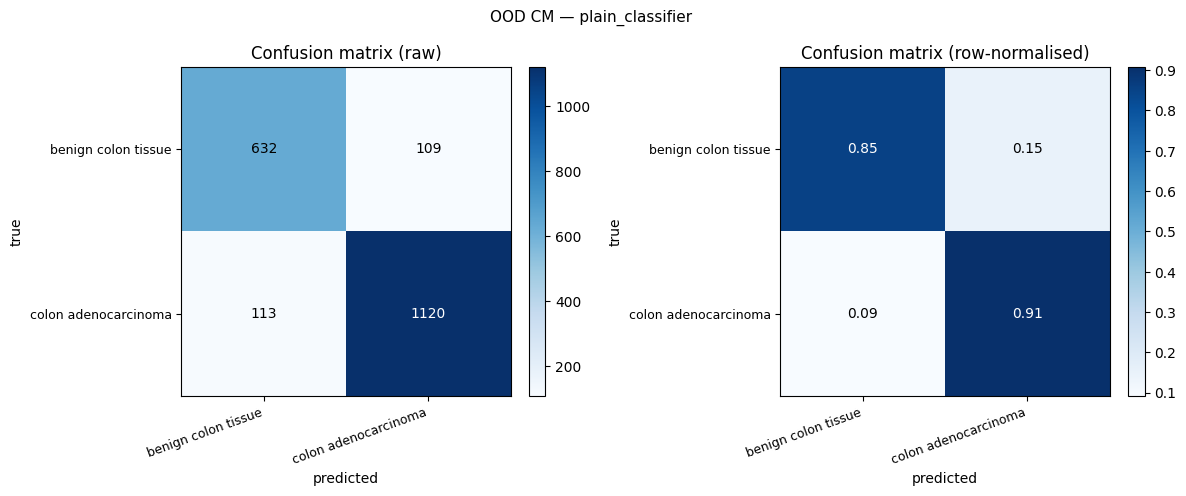

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plain_classifier_ood_cm.png


In [11]:
# --- Cell 10: plot CM ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt, cmap in [
    (axes[0], cm_raw,  "Confusion matrix (raw)",         "d",   "Blues"),
    (axes[1], cm_norm, "Confusion matrix (row-normalised)", ".2f", "Blues"),
]:
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(target_names, rotation=20, ha="right", fontsize=9)
    ax.set_yticklabels(target_names, fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"OOD CM — {VARIANT}", fontsize=11)
plt.tight_layout()
cm_path = PLOTS_DIR / f"{VARIANT}_ood_cm.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {cm_path}")


## 11 — Shared UMAP setup

Same idea as the CLIP OOD notebook: encode LC25000 full test set + NCT into the **2048-d post-BN feature space** of the plain classifier, fit a single UMAP, and reuse it across all downstream plots. Plain classifier has no text-encoded class prompts, so the UMAPs show image clusters only — no prompt stars. As a substitute, we plot the **Dense(5) classifier weight vectors** (one per class) as "class direction" markers; these are the closest-analogue to CLIP's prompt embeddings under the supervised softmax architecture.


In [12]:
# --- Cell 11: load LC25000 + encode + fit combined UMAP ---
import umap
import kagglehub

LC_SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
if LC_SPLIT_PATH.exists():
    lc_split = load_split(LC_SPLIT_PATH)
    print(f"Loaded existing split from {LC_SPLIT_PATH}")
else:
    print("Downloading LC25000 via kagglehub...")
    lc_dataset_path = kagglehub.dataset_download(
        "andrewmvd/lung-and-colon-cancer-histopathological-images"
    )
    all_paths, all_indices = discover_records(lc_dataset_path)
    lc_split = stratified_split(all_paths, all_indices,
                                val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(lc_split, LC_SPLIT_PATH)
    print(f"Built + saved split at {LC_SPLIT_PATH}")

lc_test_paths   = np.asarray(lc_split["test_paths"])
lc_test_indices = np.asarray(lc_split["test_indices"], dtype=np.int32)
print(f"\nLC25000 full test set: {len(lc_test_paths)} images")
for idx in range(len(CLASS_INFO)):
    n = int((lc_test_indices == idx).sum())
    print(f"  class {idx} ({INDEX_TO_NAME[idx]}): {n}")

lc_colon_mask    = np.isin(lc_test_indices, COLON_IDX)
lc_colon_paths   = lc_test_paths[lc_colon_mask]
lc_colon_indices = lc_test_indices[lc_colon_mask]

print(f"\nEncoding all {len(lc_test_paths)} LC25000 test images...")
lc_test_logits, lc_test_features = encode_paths(lc_test_paths)
print(f"LC25000 features: {lc_test_features.shape}")

# Get the Dense(5) weight matrix as class-direction vectors.
classifier_layer = model.get_layer("classifier")
W, b = classifier_layer.get_weights()    # W: (2048, 5)   b: (5,)
class_directions = W.T                   # (5, 2048) — one row per class
print(f"\nClassifier weight matrix: {W.shape}  -> class_directions: {class_directions.shape}")

# Fit one UMAP over [LC, NCT, 5 class directions].
print(f"\nFitting combined UMAP over {len(lc_test_features) + len(ood_features) + 5} points...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
combined = np.vstack([lc_test_features, ood_features, class_directions])
combined_2d = reducer.fit_transform(combined)

n_lc, n_nct = len(lc_test_features), len(ood_features)
lc_2d           = combined_2d[:n_lc]
nct_2d          = combined_2d[n_lc:n_lc + n_nct]
class_2d        = combined_2d[n_lc + n_nct:]       # 5 class direction positions
lc_colon_2d     = lc_2d[lc_colon_mask]
class_2d_colon  = class_2d[COLON_IDX]
print(f"  lc_2d={lc_2d.shape}  nct_2d={nct_2d.shape}  class_2d={class_2d.shape}")


Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Built + saved split at /content/histopathology-clip-lab/data/splits/lc25000_seed42.json

LC25000 full test set: 2372 images
  class 0 (benign lung tissue): 475
  class 1 (lung adenocarcinoma): 472
  class 2 (lung squamous cell carcinoma): 473
  class 3 (benign colon tissue): 477
  class 4 (colon adenocarcinoma): 475

Encoding all 2372 LC25000 test images...
LC25000 features: (2372, 2048)

Classifier weight matrix: (2048, 5)  -> class_directions: (5, 2048)

Fitting combined UMAP over 4351 points...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  lc_2d=(2372, 2)  nct_2d=(1974, 2)  class_2d=(5, 2)


## 12 — Scatter plots: NCT only and LC25000 + NCT combined

Star markers represent the Dense(5) classifier weight vectors projected into the shared UMAP space — interpret them as "what direction in feature space does the model associate with this class".


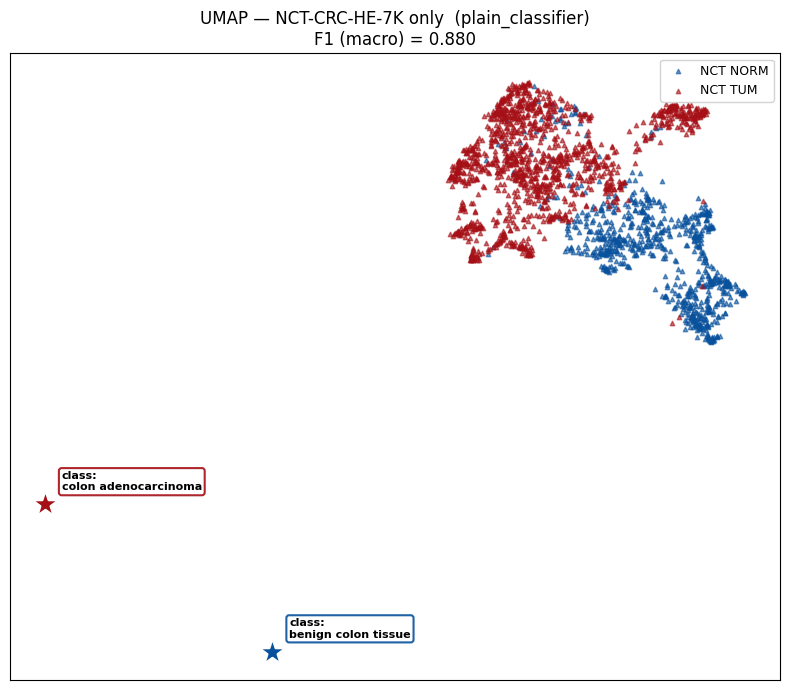

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plain_classifier_ood_umap_nct_only.png


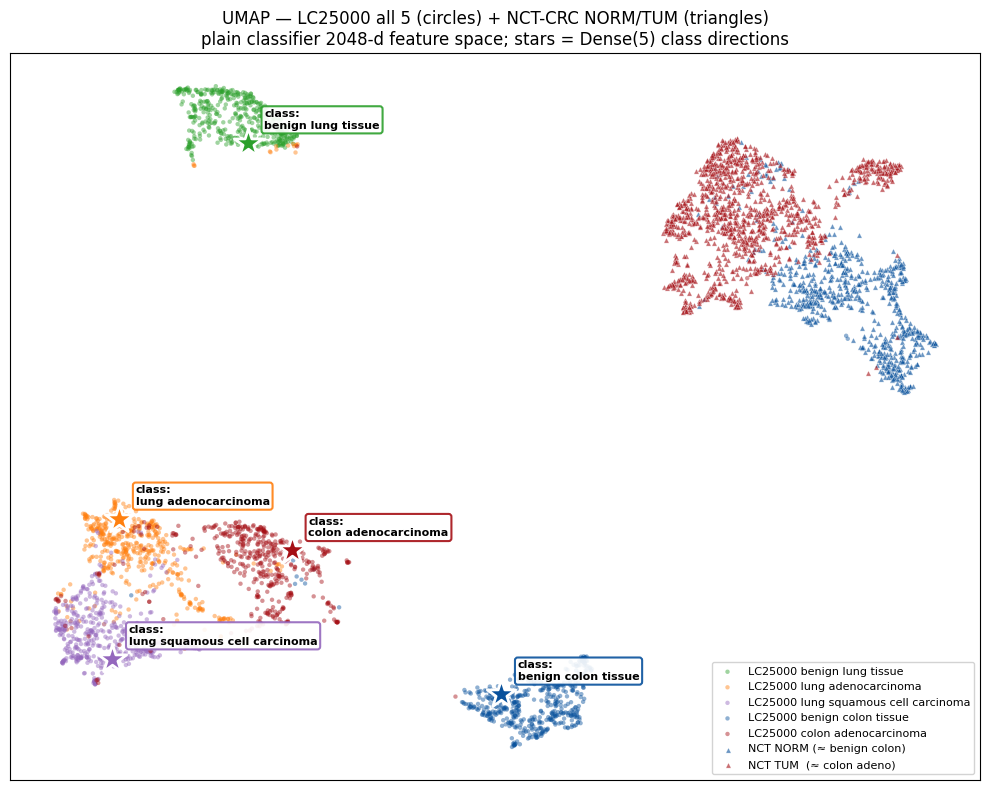

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plain_classifier_ood_umap_combined.png


In [13]:
# --- Cell 12: scatter plots ---
CLASS_COLOR = {
    0: "#2ca02c",  # benign lung tissue           — green
    1: "#ff7f0e",  # lung adenocarcinoma          — orange
    2: "#9467bd",  # lung squamous cell carcinoma — purple
    3: "#08519c",  # benign colon tissue          — blue
    4: "#a50f15",  # colon adenocarcinoma         — red
}
BENIGN_COLOR = CLASS_COLOR[3]
ADENO_COLOR  = CLASS_COLOR[4]


def draw_class_dirs(ax, class_2d_, indices, *, with_labels=True, size=460):
    for k, idx in enumerate(indices):
        color = CLASS_COLOR[idx]
        ax.scatter(class_2d_[k, 0], class_2d_[k, 1], s=size, marker="*",
                   c=color, edgecolors="white", linewidths=2.0, zorder=6)
        if with_labels:
            ax.annotate(
                f"class:\n{INDEX_TO_NAME[idx]}",
                (class_2d_[k, 0], class_2d_[k, 1]),
                xytext=(12, 10), textcoords="offset points",
                fontsize=8, fontweight="bold", zorder=7,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor=color, alpha=0.9, linewidth=1.5),
            )


# Plot 1 — NCT only.
fig1, ax1 = plt.subplots(figsize=(8, 7))
for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
    mask = (ood_nct_labels == nct_cls)
    ax1.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=10, alpha=0.6,
                c=color, marker="^", label=f"NCT {nct_cls}")
draw_class_dirs(ax1, class_2d_colon, COLON_IDX)
ax1.legend(loc="best", fontsize=9, framealpha=0.85)
ax1.set_xticks([]); ax1.set_yticks([])
ax1.set_title(f"UMAP — NCT-CRC-HE-7K only  ({VARIANT})\nF1 (macro) = {macro_f1:.3f}")
plt.tight_layout()
p1 = PLOTS_DIR / f"{VARIANT}_ood_umap_nct_only.png"
fig1.savefig(p1, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p1}")

# Plot 2 — combined.
fig2, ax2 = plt.subplots(figsize=(10, 8))
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax2.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=10, alpha=0.45,
                c=CLASS_COLOR[idx], marker="o",
                label=f"LC25000 {INDEX_TO_NAME[idx]}", edgecolors="none")
ax2.scatter(nct_2d[ood_nct_labels == "NORM", 0], nct_2d[ood_nct_labels == "NORM", 1],
            s=14, alpha=0.6, c=BENIGN_COLOR, marker="^",
            label="NCT NORM (≈ benign colon)", edgecolors="white", linewidths=0.3)
ax2.scatter(nct_2d[ood_nct_labels == "TUM", 0], nct_2d[ood_nct_labels == "TUM", 1],
            s=14, alpha=0.6, c=ADENO_COLOR, marker="^",
            label="NCT TUM  (≈ colon adeno)", edgecolors="white", linewidths=0.3)
draw_class_dirs(ax2, class_2d, list(range(len(CLASS_INFO))))
ax2.legend(loc="best", fontsize=8, framealpha=0.85)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title(f"UMAP — LC25000 all 5 (circles) + NCT-CRC NORM/TUM (triangles)\nplain classifier 2048-d feature space; stars = Dense(5) class directions")
plt.tight_layout()
p2 = PLOTS_DIR / f"{VARIANT}_ood_umap_combined.png"
fig2.savefig(p2, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p2}")


## 13 — Thumbnail plots


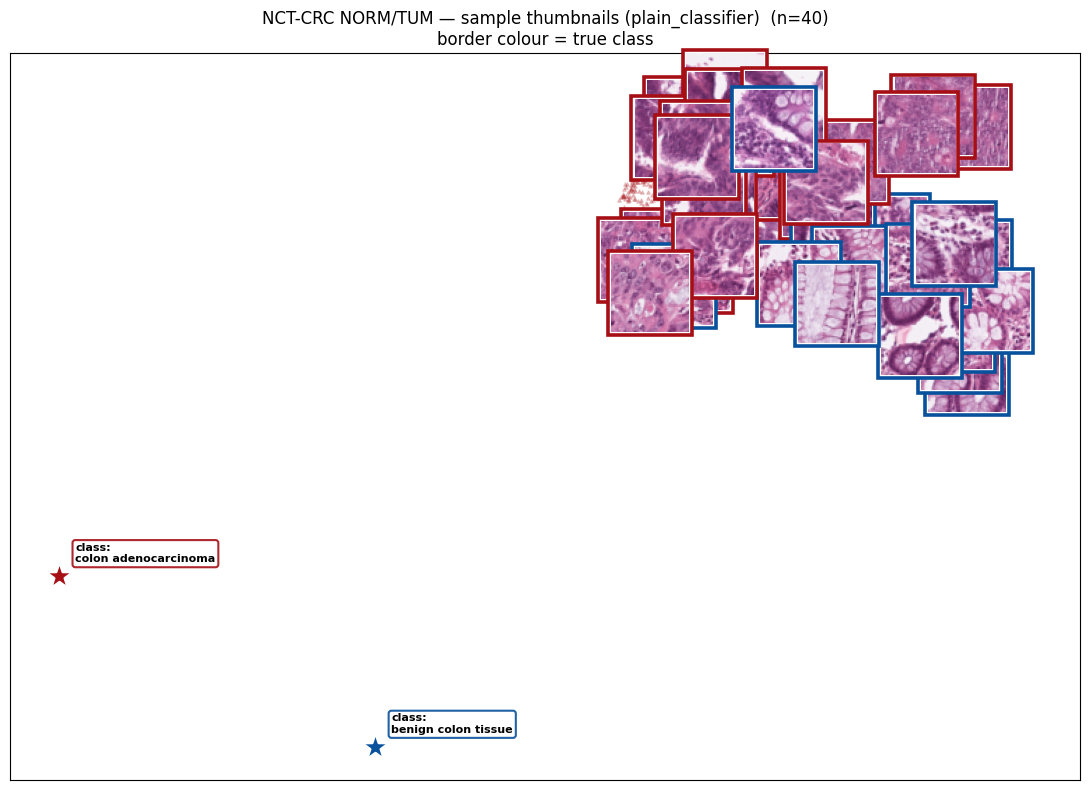

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plain_classifier_ood_umap_nct_thumbnails.png


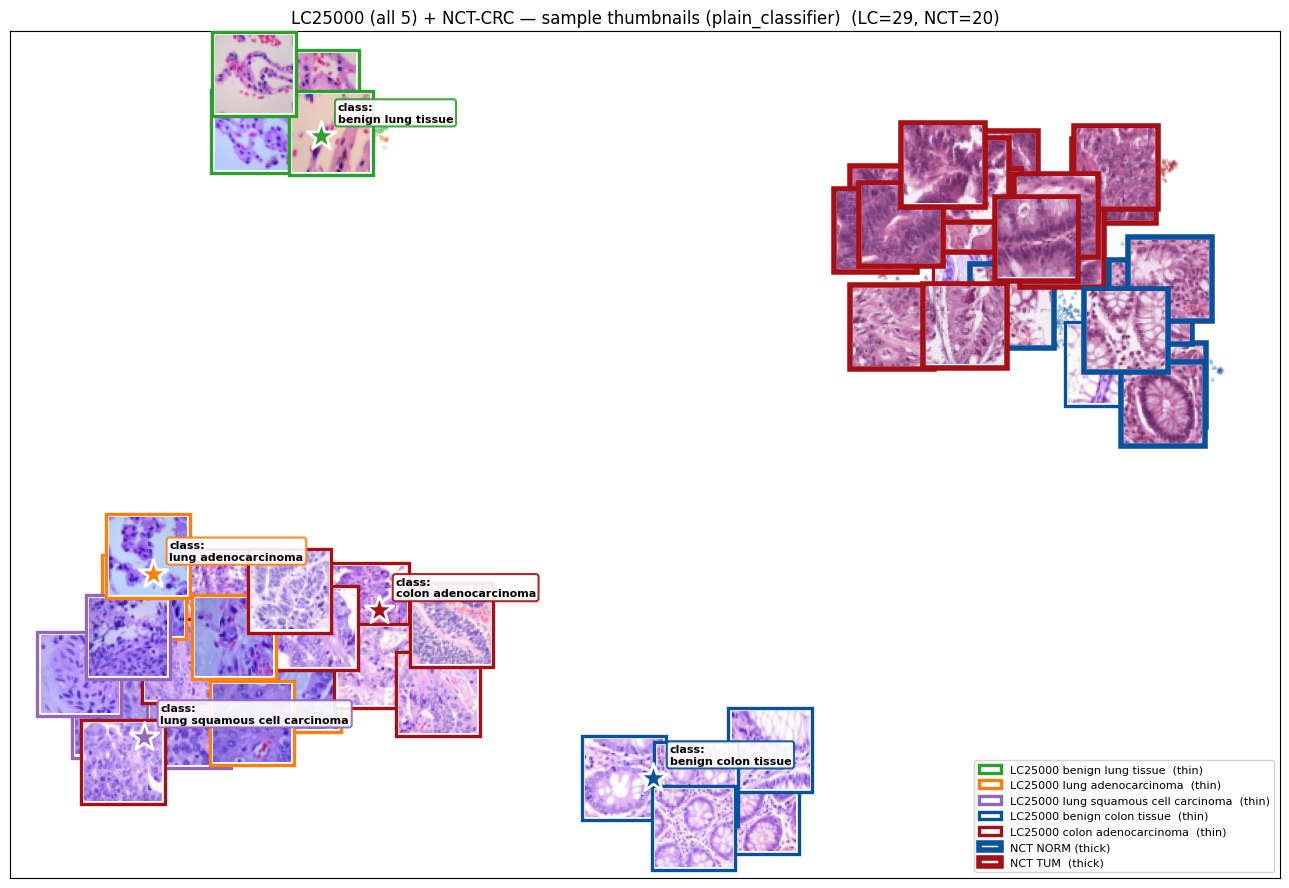

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plain_classifier_ood_umap_combined_thumbnails.png


In [14]:
# --- Cell 13: thumbnail plots ---
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Patch


def _read_thumb(path, size=(56, 56)):
    try:
        im = Image.open(path).convert("RGB").resize(size, Image.BILINEAR)
        return np.asarray(im)
    except Exception:
        return np.full((size[1], size[0], 3), 200, dtype=np.uint8)


def _layout_thumbnails(ax, coords, paths, class_colors, *, max_thumbs=40,
                       thumb_size=(56, 56), min_dist_frac=0.045, seed=42,
                       border_width=2.6):
    coords = np.asarray(coords)
    rng = np.random.default_rng(seed)
    x_range = float(coords[:, 0].max() - coords[:, 0].min())
    y_range = float(coords[:, 1].max() - coords[:, 1].min())
    min_dist = min_dist_frac * min(x_range, y_range)
    idx = np.arange(len(coords)); rng.shuffle(idx)
    placed = []
    for i in idx:
        x, y = float(coords[i, 0]), float(coords[i, 1])
        if any((x - px) ** 2 + (y - py) ** 2 < min_dist ** 2 for (px, py) in placed):
            continue
        thumb = _read_thumb(paths[i], size=thumb_size)
        ab = AnnotationBbox(
            OffsetImage(thumb, zoom=1.0), (x, y),
            frameon=True, pad=0.22,
            bboxprops=dict(linewidth=border_width, edgecolor=class_colors[i]),
        )
        ax.add_artist(ab)
        placed.append((x, y))
        if len(placed) >= max_thumbs:
            break
    return len(placed)


# Plot 3 — NCT-only thumbnails.
fig3, ax3 = plt.subplots(figsize=(11, 8))
for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
    mask = (ood_nct_labels == nct_cls)
    ax3.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=6, alpha=0.20, c=color, marker="^")
nct_thumb_colors = [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))]
n_thumbs_3 = _layout_thumbnails(
    ax3, nct_2d, list(ood_paths), nct_thumb_colors,
    max_thumbs=40, min_dist_frac=0.06, seed=SEED,
)
draw_class_dirs(ax3, class_2d_colon, COLON_IDX, with_labels=True)
ax3.set_xticks([]); ax3.set_yticks([])
ax3.set_title(f"NCT-CRC NORM/TUM — sample thumbnails ({VARIANT})  (n={n_thumbs_3})\nborder colour = true class")
plt.tight_layout()
p3 = PLOTS_DIR / f"{VARIANT}_ood_umap_nct_thumbnails.png"
fig3.savefig(p3, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p3}")


# Plot 4 — combined thumbnails.
fig4, ax4 = plt.subplots(figsize=(13, 9))
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax4.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=6, alpha=0.18, c=CLASS_COLOR[idx], marker="o")
ax4.scatter(nct_2d[ood_nct_labels == "NORM", 0], nct_2d[ood_nct_labels == "NORM", 1],
            s=6, alpha=0.20, c=BENIGN_COLOR, marker="^")
ax4.scatter(nct_2d[ood_nct_labels == "TUM", 0], nct_2d[ood_nct_labels == "TUM", 1],
            s=6, alpha=0.20, c=ADENO_COLOR, marker="^")

lc_thumb_colors  = [CLASS_COLOR[int(lc_test_indices[i])] for i in range(len(lc_test_paths))]
nct_thumb_colors = [CLASS_COLOR[int(ood_lc_indices[i])]   for i in range(len(ood_paths))]
n_lc_thumbs  = _layout_thumbnails(
    ax4, lc_2d, list(lc_test_paths), lc_thumb_colors,
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4,
)
n_nct_thumbs = _layout_thumbnails(
    ax4, nct_2d, list(ood_paths), nct_thumb_colors,
    max_thumbs=20, min_dist_frac=0.06, seed=SEED + 1, border_width=4.0,
)
draw_class_dirs(ax4, class_2d, list(range(len(CLASS_INFO))), with_labels=True)

legend_elements = [
    Patch(facecolor="white", edgecolor=CLASS_COLOR[i], linewidth=2.4,
          label=f"LC25000 {INDEX_TO_NAME[i]}  (thin)")
    for i in range(len(CLASS_INFO))
] + [
    Patch(facecolor="white", edgecolor=BENIGN_COLOR, linewidth=4.0, label="NCT NORM (thick)"),
    Patch(facecolor="white", edgecolor=ADENO_COLOR,  linewidth=4.0, label="NCT TUM  (thick)"),
]
ax4.legend(handles=legend_elements, loc="best", fontsize=8, framealpha=0.85)
ax4.set_xticks([]); ax4.set_yticks([])
ax4.set_title(f"LC25000 (all 5) + NCT-CRC — sample thumbnails ({VARIANT})  (LC={n_lc_thumbs}, NCT={n_nct_thumbs})")
plt.tight_layout()
p4 = PLOTS_DIR / f"{VARIANT}_ood_umap_combined_thumbnails.png"
fig4.savefig(p4, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p4}")


## 14 — Three-dataset comparison panel (same layout as CLIP eval)


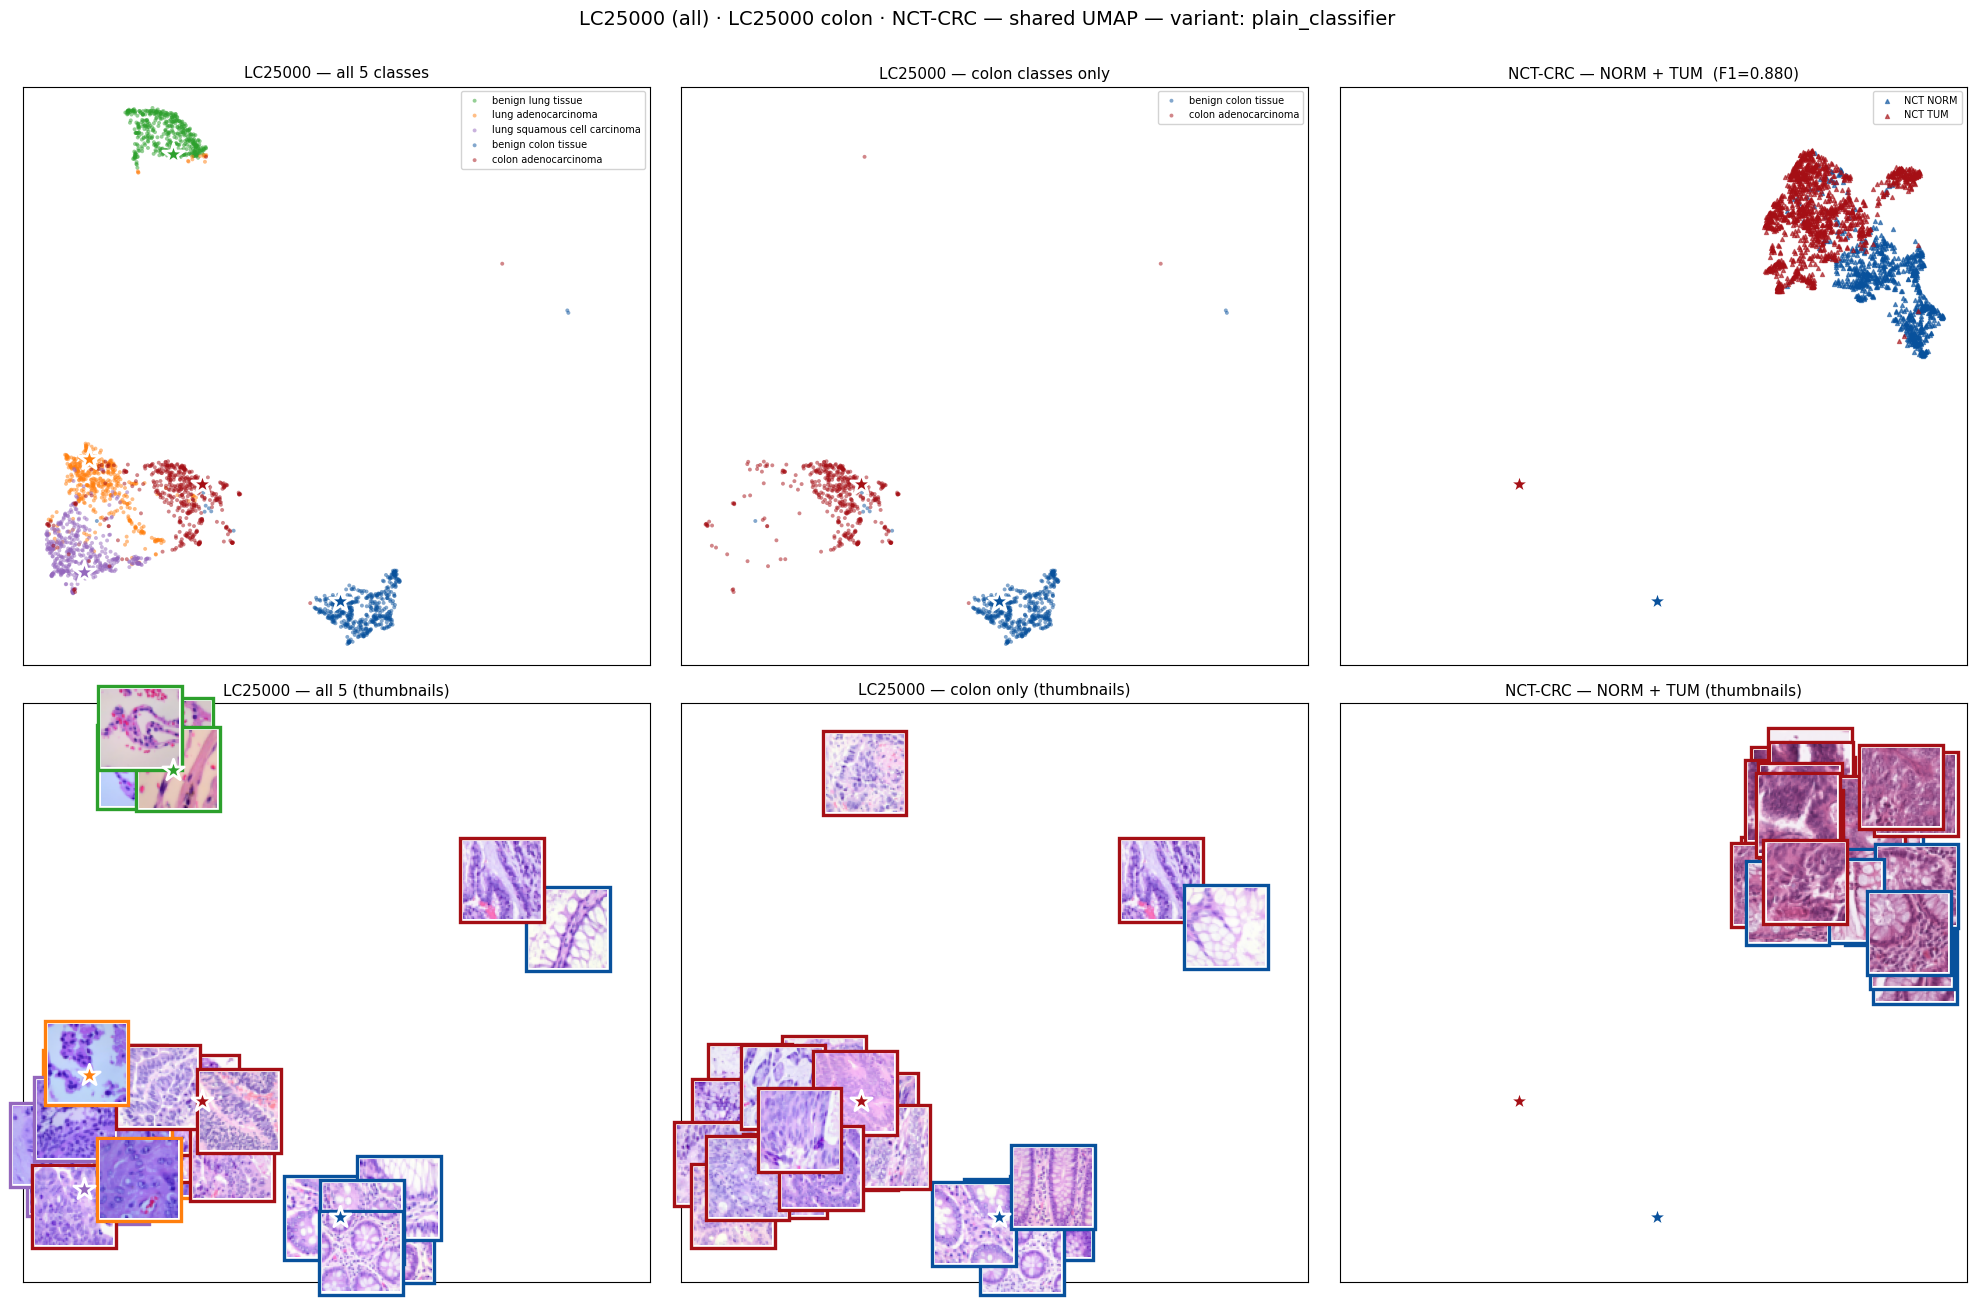

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plain_classifier_ood_umap_grid.png


In [15]:
# --- Cell 14: 2x3 comparison panel ---
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

x_min = min(lc_2d[:, 0].min(), nct_2d[:, 0].min(), class_2d[:, 0].min())
x_max = max(lc_2d[:, 0].max(), nct_2d[:, 0].max(), class_2d[:, 0].max())
y_min = min(lc_2d[:, 1].min(), nct_2d[:, 1].min(), class_2d[:, 1].min())
y_max = max(lc_2d[:, 1].max(), nct_2d[:, 1].max(), class_2d[:, 1].max())
pad_x = 0.04 * (x_max - x_min); pad_y = 0.04 * (y_max - y_min)
XLIM = (x_min - pad_x, x_max + pad_x)
YLIM = (y_min - pad_y, y_max + pad_y)


def _set_box(ax, title):
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11)


# ROW 1 — scatter.
ax = axes[0, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o", label=INDEX_TO_NAME[idx], edgecolors="none")
draw_class_dirs(ax, class_2d, list(range(len(CLASS_INFO))), with_labels=False, size=260)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_set_box(ax, "LC25000 — all 5 classes")

ax = axes[0, 1]
for idx in COLON_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o", label=INDEX_TO_NAME[idx], edgecolors="none")
draw_class_dirs(ax, class_2d_colon, COLON_IDX, with_labels=False, size=260)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_set_box(ax, "LC25000 — colon classes only")

ax = axes[0, 2]
for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
    mask = (ood_nct_labels == nct_cls)
    ax.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=8, alpha=0.6,
               c=color, marker="^", label=f"NCT {nct_cls}")
draw_class_dirs(ax, class_2d_colon, COLON_IDX, with_labels=False, size=260)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_set_box(ax, f"NCT-CRC — NORM + TUM  (F1={macro_f1:.3f})")

# ROW 2 — thumbnails.
ax = axes[1, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.15, c=CLASS_COLOR[idx], marker="o")
_layout_thumbnails(
    ax, lc_2d, list(lc_test_paths),
    [CLASS_COLOR[int(lc_test_indices[i])] for i in range(len(lc_test_paths))],
    max_thumbs=35, min_dist_frac=0.06, seed=SEED, border_width=2.4,
)
draw_class_dirs(ax, class_2d, list(range(len(CLASS_INFO))), with_labels=False, size=260)
_set_box(ax, "LC25000 — all 5 (thumbnails)")

ax = axes[1, 1]
for idx in COLON_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.15, c=CLASS_COLOR[idx], marker="o")
_layout_thumbnails(
    ax, lc_colon_2d, list(lc_colon_paths),
    [CLASS_COLOR[int(lc_colon_indices[i])] for i in range(len(lc_colon_paths))],
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4,
)
draw_class_dirs(ax, class_2d_colon, COLON_IDX, with_labels=False, size=260)
_set_box(ax, "LC25000 — colon only (thumbnails)")

ax = axes[1, 2]
for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
    mask = (ood_nct_labels == nct_cls)
    ax.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=5, alpha=0.20, c=color, marker="^")
_layout_thumbnails(
    ax, nct_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4,
)
draw_class_dirs(ax, class_2d_colon, COLON_IDX, with_labels=False, size=260)
_set_box(ax, "NCT-CRC — NORM + TUM (thumbnails)")

fig.suptitle(f"LC25000 (all) · LC25000 colon · NCT-CRC — shared UMAP — variant: {VARIANT}",
             fontsize=14, y=1.005)
plt.tight_layout()
p_grid = PLOTS_DIR / f"{VARIANT}_ood_umap_grid.png"
fig.savefig(p_grid, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p_grid}")


## Summary

Run-time output (filenames use `plain_classifier_` prefix):
- `results/metrics/exp_07_ood_eval/plain_classifier_ood_classification.json`
- `results/confusion_matrices/exp_07_ood_eval/plain_classifier_ood_cm_{raw,norm}.npy`
- `results/plots/exp_07_ood_eval/plain_classifier_ood_cm.png`
- `results/plots/exp_07_ood_eval/plain_classifier_ood_umap_nct_only.png`
- `results/plots/exp_07_ood_eval/plain_classifier_ood_umap_combined.png`
- `results/plots/exp_07_ood_eval/plain_classifier_ood_umap_nct_thumbnails.png`
- `results/plots/exp_07_ood_eval/plain_classifier_ood_umap_combined_thumbnails.png`
- `results/plots/exp_07_ood_eval/plain_classifier_ood_umap_grid.png`

**Prereq:** the plain classifier checkpoint must exist on Drive at `exp_03_plain_classifier/plain_classifier/weights.weights.h5`. Run `experiments/exp_03_plain_classifier/ResNet50_plain_classifier.ipynb` from the `exp_07` branch (now points to the corrected preprocessing pipeline) first.
